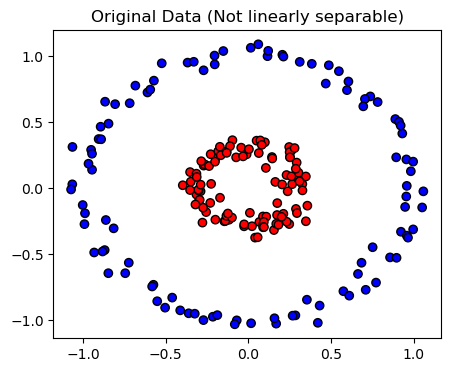

In [1]:
# Demonstration of the SVM Kernel Trick

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---
# 1) Create NON-linearly separable data
# ---
X, y = make_circles(n_samples=200, factor=0.3, noise=0.05, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", edgecolor="k")
plt.title("Original Data (Not linearly separable)")
plt.show()

In [6]:
# 2) Train SVM with different kernels
# ---
kernels = {
    "Linear": SVC(kernel="linear"),
    "Polynomial": SVC(kernel="poly", degree=3),
    "RBF": SVC(kernel="rbf", gamma=1.5)
}

for name, model in kernels.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"{name} Kernel Accuracy: {acc:.3f}")

Linear Kernel Accuracy: 0.690
Polynomial Kernel Accuracy: 0.710
RBF Kernel Accuracy: 1.000


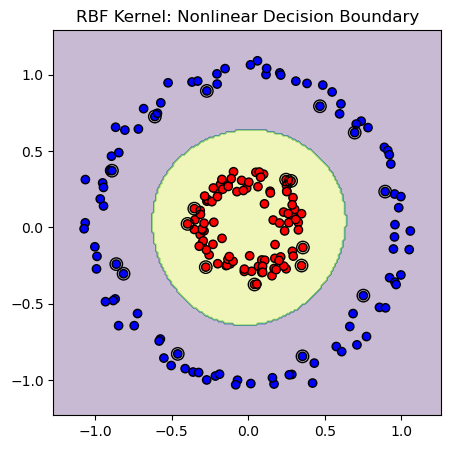

In [7]:
# 3) Visualize decision boundary for RBF kernel
# ---
rbf_model = kernels["RBF"]

# Create a grid of points
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.2, X[:,0].max()+0.2, 200),
    np.linspace(X[:,1].min()-0.2, X[:,1].max()+0.2, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = rbf_model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", edgecolor="k")
plt.scatter(
    rbf_model.support_vectors_[:,0],
    rbf_model.support_vectors_[:,1],
    s=80, facecolors="none", edgecolors="black"
)
plt.title("RBF Kernel: Nonlinear Decision Boundary")
plt.show()